In [2]:
!pip install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 12.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import SimpleITK as sitk
import cv2
import numpy as np
from PIL import Image
import os
from scipy import ndimage

# Breast Cancer (Context)

Breast cancer is a disease in which abnormal cells in breast tissue grow uncontrollably (Shakil Malik & Masood, 2022). It is the most common type of cancer in the world, with 2.3 million new cases in 2024, and the fifth leading cause of cancer death, with 670,000 cases, according to the International Agency for Research on Cancer (IARC). As can be seen in Figure 1.

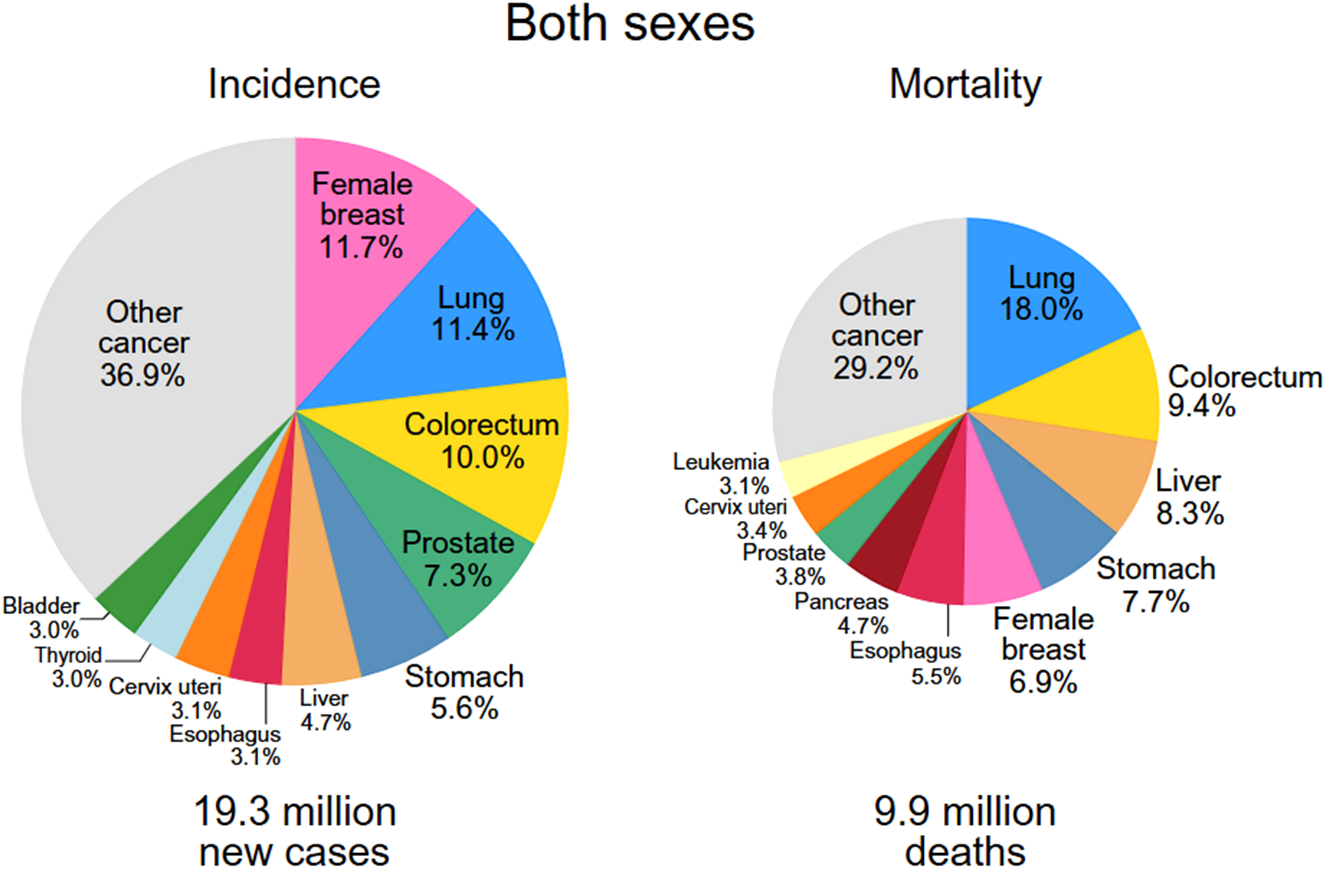

Because of this, health organizations promote early detection as the best strategy for saving lives, since providing treatment in the initial phase increases the success rate and, with it, the probability of survival. However, it is not until a biopsy is performed that a definitive diagnosis of the tumor can be made. Two types of tests are performed on the extracted tissue: histopathological and immunohistochemical. The latter allows us to characterize the molecular subtype of breast cancer using the following molecular biomarkers: estrogen receptor (ER), progesterone receptor (PR), and human epidermal growth factor receptor 2 (HER2).

The aforementioned biomarkers allow breast cancer to be classified into four main molecular subtypes: luminal A, luminal B, HER2-positive, and triple-negative. These range from best to worst prognosis. Figure 2 shows their classification.

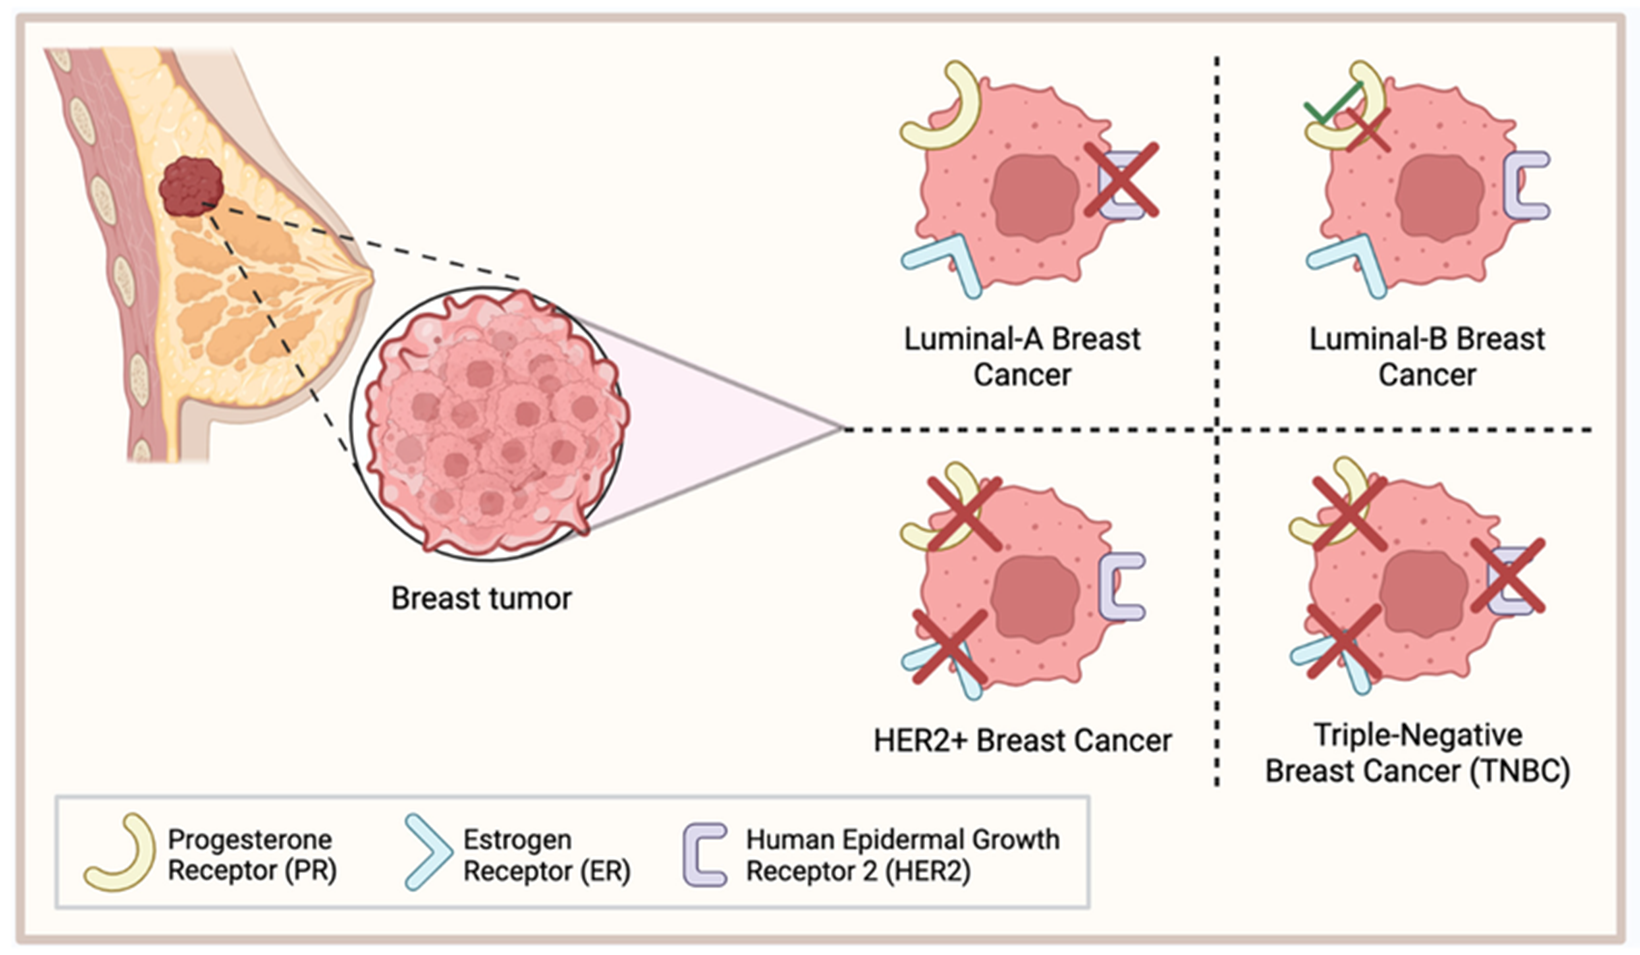

Triple-negative tumors may exhibit morphological features typical of benign lesions (oval or round shapes and circumscribed edges) on mammography and ultrasound. This benign appearance can lead to a misdiagnosis of triple-negative cancer, resulting in delays in diagnosis and treatment. Therefore, the aim is to assist in the classification of triple-negative tumors versus benign lesions.

This is why a mammography database was selected in order to study this problem.

# Mammo-Bench

## Key Features

## 📊 Dataset Statistics
- **Total Images**: 74,436 mammographic images
- **Patient Coverage**: 26,500 patients
- **Geographic Diversity**: Data from 8 countries
- **Source Datasets**: 7 public resources

## 📋 Comprehensive Annotations
- Case labels (Normal/Benign/Malignant)
- Breast density classifications (ACR A-D)
- BI-RADS scores (0-6)
- Molecular subtypes (Luminal A, Luminal B, HER2, TNBC)
- Abnormality types (mass, calcification, or both)

## 🔍 Preprocessing Pipeline
Our robust preprocessing pipeline ensures consistency while preserving clinically relevant features:
1. Data format standardization
2. Binary Mask Generation
3. Breast Segmentation and Pectoral Muscle Removal using [OpenBreast](https://github.com/spertuz/openbreast) toolkit
5. Intelligent Cropping to remove extraneous areas

In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/mammo-bench_molecular_subtype.csv')
df2 = pd.read_csv('/content/drive/MyDrive/mammo-bench.csv')

print("DataFrame 1 (mammo-bench_molecular_subtype.csv):")
display(df1.head())

print("\nDataFrame 2 (mammo-bench.csv):")
display(df2.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame 1 (mammo-bench_molecular_subtype.csv):


/tmp/ipython-input-3606185615.py:9: DtypeWarning: Columns (7,8,11,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('/content/drive/MyDrive/mammo-bench.csv')


,source_dataset,laterality,view,preprocessed_image_path,classification,density,BIRADS,abnormality,molecular_subtype,raw_image_path,mask_path,ROI_path,x,y,radius,subject_age,source_subjectID,original_source_path
0,cmmd,L,CC,Preprocessed_Dataset/cmmd/cmmd_1026.jpg,Malignant,NaN,NaN,calcification,Luminal B,Original_Dataset/cmmd/cmmd_1026.jpg,Masks/cmmd/cmmd_1026.jpg,NaN,NaN,NaN,NaN,64.0,D2-0001,CMMD/CMMD/D2-0001/07-18-2011-NA-NA-75485/1.000...
1,cmmd,L,CC,Preprocessed_Dataset/cmmd/cmmd_1027.jpg,Malignant,NaN,NaN,calcification,Luminal B,Original_Dataset/cmmd/cmmd_1027.jpg,Masks/cmmd/cmmd_1027.jpg,NaN,NaN,NaN,NaN,69.0,D2-0002,CMMD/CMMD/D2-0002/07-18-2010-NA-NA-26354/1.000...
2,cmmd,L,CC,Preprocessed_Dataset/cmmd/cmmd_1028.jpg,Malignant,NaN,NaN,calcification,Luminal B,Original_Dataset/cmmd/cmmd_1028.jpg,Masks/cmmd/cmmd_1028.jpg,NaN,NaN,NaN,NaN,44.0,D2-0003,CMMD/CMMD/D2-0003/07-18-2010-NA-NA-57046/1.000...
3,cmmd,L,CC,Preprocessed_Dataset/cmmd/cmmd_1029.jpg,Malignant,NaN,NaN,calcification,Luminal B,Original_Dataset/cmmd/cmmd_1029.jpg,Masks/cmmd/cmmd_1029.jpg,NaN,NaN,NaN,NaN,38.0,D2-0004,CMMD/CMMD/D2-0004/07-18-2010-NA-NA-29234/1.000...
4,cmmd,L,CC,Preprocessed_Dataset/cmmd/cmmd_1030.jpg,Malignant,NaN,NaN,calcification,HER2-enriched,Original_Dataset/cmmd/cmmd_1030.jpg,Masks/cmmd/cmmd_1030.jpg,NaN,NaN,NaN,NaN,41.0,D2-0005,CMMD/CMMD/D2-0005/07-18-2010-NA-NA-26051/1.000...



DataFrame 2 (mammo-bench.csv):


,source_dataset,laterality,view,preprocessed_image_path,classification,density,BIRADS,abnormality,molecular_subtype,raw_image_path,mask_path,ROI_path,x,y,radius,subject_age,source_subjectID,original_source_path
0,inbreast,R,CC,Preprocessed_Dataset/inbreast/inbreast_0.jpg,Normal,D,1.0,NaN,NaN,Original_Dataset/inbreast/inbreast_0.jpg,Masks/inbreast/inbreast_0.jpg,NaN,NaN,NaN,NaN,NaN,22678622,INbreast/AllDICOMs/22678622_61b13c59bcba149e_M...
1,inbreast,L,CC,Preprocessed_Dataset/inbreast/inbreast_1.jpg,Benign,D,3.0,NaN,NaN,Original_Dataset/inbreast/inbreast_1.jpg,Masks/inbreast/inbreast_1.jpg,NaN,NaN,NaN,NaN,NaN,22678646,INbreast/AllDICOMs/22678646_61b13c59bcba149e_M...
2,inbreast,R,MLO,Preprocessed_Dataset/inbreast/inbreast_2.jpg,Normal,D,1.0,NaN,NaN,Original_Dataset/inbreast/inbreast_2.jpg,Masks/inbreast/inbreast_2.jpg,NaN,NaN,NaN,NaN,NaN,22678670,INbreast/AllDICOMs/22678670_61b13c59bcba149e_M...
3,inbreast,L,MLO,Preprocessed_Dataset/inbreast/inbreast_3.jpg,Benign,D,3.0,NaN,NaN,Original_Dataset/inbreast/inbreast_3.jpg,Masks/inbreast/inbreast_3.jpg,NaN,NaN,NaN,NaN,NaN,22678694,INbreast/AllDICOMs/22678694_61b13c59bcba149e_M...
4,inbreast,R,CC,Preprocessed_Dataset/inbreast/inbreast_4.jpg,Malignant,B,5.0,NaN,NaN,Original_Dataset/inbreast/inbreast_4.jpg,Masks/inbreast/inbreast_4.jpg,NaN,NaN,NaN,NaN,NaN,22614074,INbreast/AllDICOMs/22614074_6bd24a0a42c19ce1_M...


In [ ]:
df1.columns

Index(['source_dataset', 'laterality', 'view', 'preprocessed_image_path',
       'classification', 'density', 'BIRADS', 'abnormality',
       'molecular_subtype', 'raw_image_path', 'mask_path', 'ROI_path', 'x',
       'y', 'radius', 'subject_age', 'source_subjectID',
       'original_source_path'],
      dtype='object')

/tmp/ipython-input-1696059557.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=values_df2.index, y=values_df2.values, palette="magma")


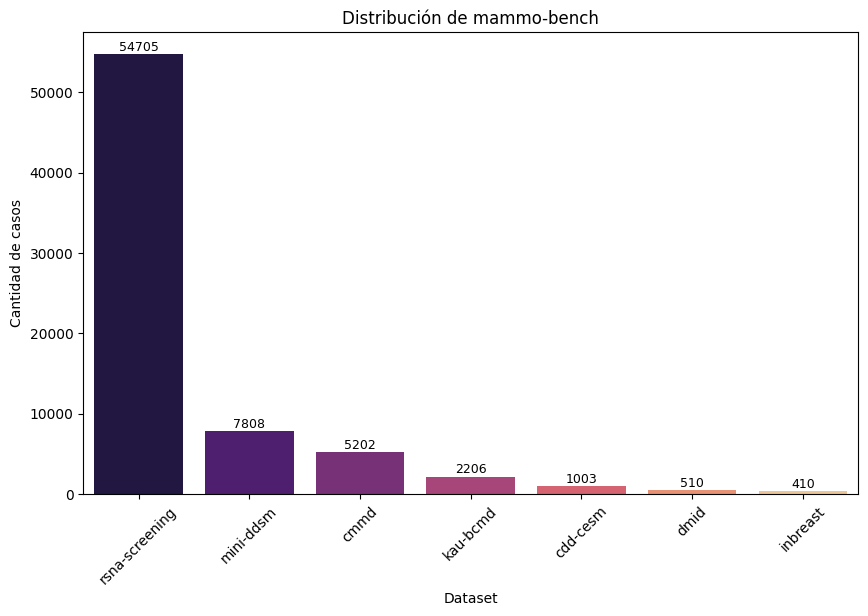

In [ ]:
values_df2 = df2['source_dataset'].value_counts()

plt.figure(figsize=(10,6))
ax2 = sns.barplot(x=values_df2.index, y=values_df2.values, palette="magma")
plt.title("Distribución de mammo-bench")
plt.ylabel("Cantidad de casos")
plt.xlabel("Dataset")
plt.xticks(rotation=45)

for i, v in enumerate(values_df2.values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=9)

plt.show()


Distribución de casos en CMMD:
classification
Malignant    4094
Benign       1108
Name: count, dtype: int64


/tmp/ipython-input-2207634037.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=cmmd_counts.index, y=cmmd_counts.values, palette="Set2")


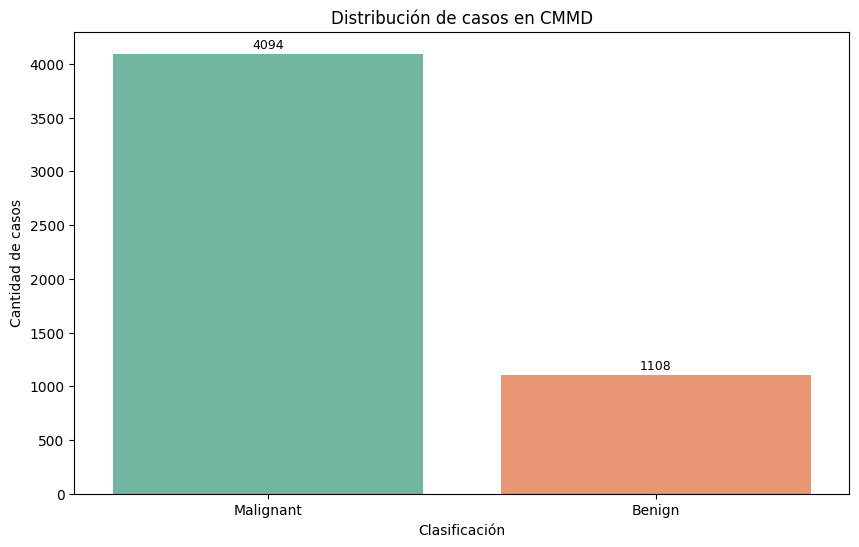

In [ ]:
cmmd_data = df2[df2['source_dataset'] == 'cmmd']

cmmd_counts = cmmd_data['classification'].value_counts()

print("Distribución de casos en CMMD:")
print(cmmd_counts)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=cmmd_counts.index, y=cmmd_counts.values, palette="Set2")
plt.title("Distribución de casos en CMMD")
plt.ylabel("Cantidad de casos")
plt.xlabel("Clasificación")

for i, v in enumerate(cmmd_counts.values):
    plt.text(i, v + 20, str(v), ha='center', va='bottom', fontsize=9)

plt.show()


/tmp/ipython-input-2215700689.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=values_df1.index, y=values_df1.values, palette="viridis")


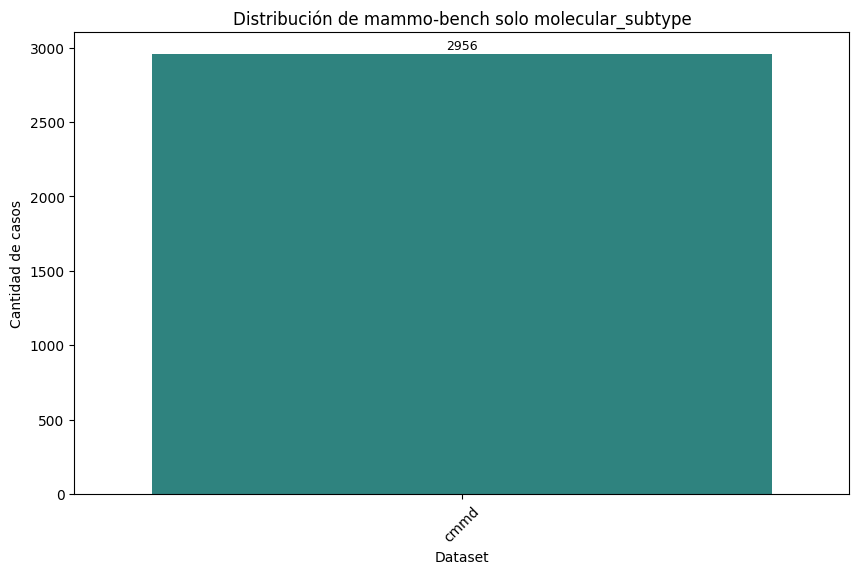

In [ ]:
values_df1 = df1['source_dataset'].value_counts()
plt.figure(figsize=(10,6))
ax1 = sns.barplot(x=values_df1.index, y=values_df1.values, palette="viridis")
plt.title("Distribución de mammo-bench solo molecular_subtype")
plt.ylabel("Cantidad de casos")
plt.xlabel("Dataset")
plt.xticks(rotation=45)

for i, v in enumerate(values_df1.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontsize=9)

plt.show()

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   source_dataset           2956 non-null   object 
 1   laterality               2956 non-null   object 
 2   view                     2956 non-null   object 
 3   preprocessed_image_path  2956 non-null   object 
 4   classification           2956 non-null   object 
 5   density                  0 non-null      float64
 6   BIRADS                   0 non-null      float64
 7   abnormality              2956 non-null   object 
 8   molecular_subtype        2956 non-null   object 
 9   raw_image_path           2956 non-null   object 
 10  mask_path                2956 non-null   object 
 11  ROI_path                 0 non-null      float64
 12  x                        0 non-null      float64
 13  y                        0 non-null      float64
 14  radius                  

Distribución de casos en CMMD:
classification
Malignant    2944
Benign         12
Name: count, dtype: int64


/tmp/ipython-input-1908174060.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=cmmd_counts.index, y=cmmd_counts.values, palette="Set2")


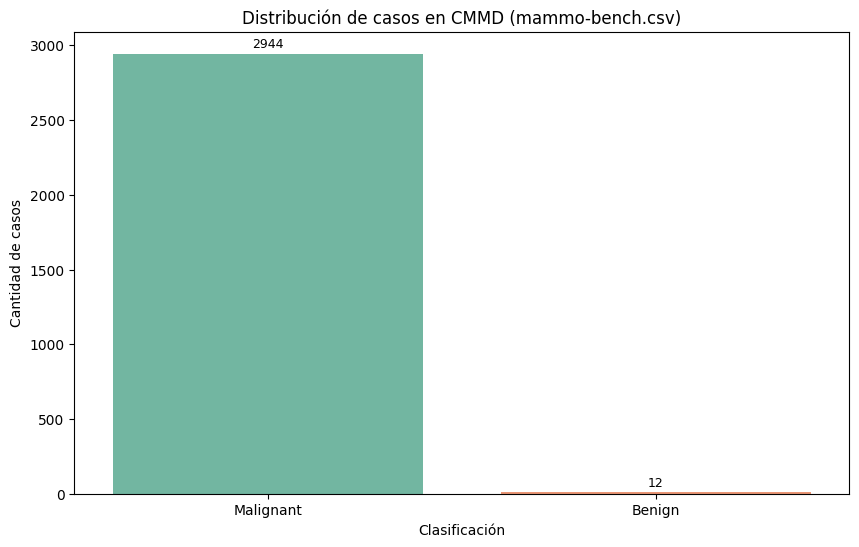

In [ ]:
cmmd_data = df1[df1['source_dataset'] == 'cmmd']

cmmd_counts = cmmd_data['classification'].value_counts()

print("Distribución de casos en CMMD:")
print(cmmd_counts)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=cmmd_counts.index, y=cmmd_counts.values, palette="Set2")
plt.title("Distribución de casos en CMMD (mammo-bench.csv)")
plt.ylabel("Cantidad de casos")
plt.xlabel("Clasificación")

for i, v in enumerate(cmmd_counts.values):
    plt.text(i, v + 20, str(v), ha='center', va='bottom', fontsize=9)

plt.show()


Distribución de casos en CMMD:
molecular_subtype
Luminal B          1482
Luminal A           600
HER2-enriched       532
triple negative     342
Name: count, dtype: int64


/tmp/ipython-input-4166947681.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=cmmd_counts.index, y=cmmd_counts.values, palette="Set2")


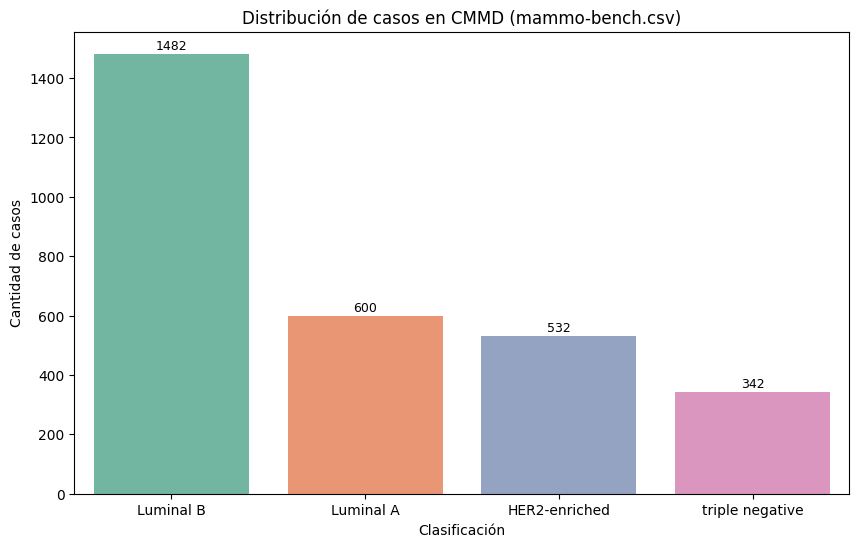

In [ ]:
cmmd_data = df1[df1['source_dataset'] == 'cmmd']

cmmd_counts = cmmd_data['molecular_subtype'].value_counts()

print("Distribución de casos en CMMD:")
print(cmmd_counts)

plt.figure(figsize=(10 ,6))
ax = sns.barplot(x=cmmd_counts.index, y=cmmd_counts.values, palette="Set2")
plt.title("Distribución de casos en CMMD (mammo-bench.csv)")
plt.ylabel("Cantidad de casos")
plt.xlabel("Clasificación")

for i, v in enumerate(cmmd_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=9)

plt.show()

Distribución de casos Benignos por subtipo molecular:
molecular_subtype
Luminal B        8
HER2-enriched    2
Luminal A        2
Name: count, dtype: int64


/tmp/ipython-input-1145159697.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=benign_counts.index, y=benign_counts.values, palette="Blues_d")


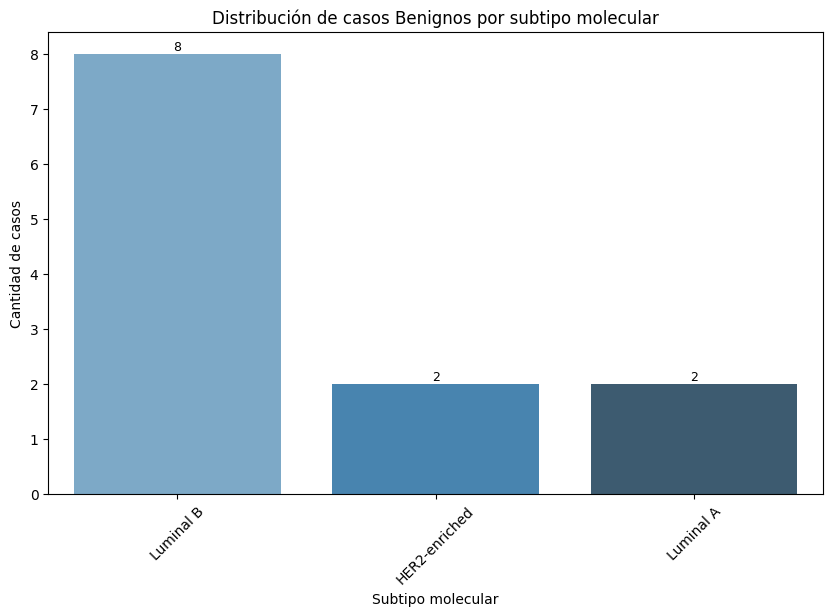

In [ ]:
benign_data = df2[df2['classification'] == 'Benign']

benign_counts = benign_data['molecular_subtype'].value_counts()

print("Distribución de casos Benignos por subtipo molecular:")
print(benign_counts)

plt.figure(figsize=(10 , 6))
ax = sns.barplot(x=benign_counts.index, y=benign_counts.values, palette="Blues_d")
plt.title("Distribución de casos Benignos por subtipo molecular")
plt.ylabel("Cantidad de casos")
plt.xlabel("Subtipo molecular")
plt.xticks(rotation=45)

for i, v in enumerate(benign_counts.values):
    plt.text(i, v + 0.02, str(v), ha='center', va='bottom', fontsize=9)

plt.show()

# Data loading and visualization

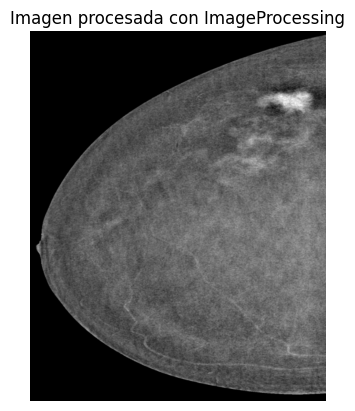

In [5]:
img_path = "/content/SCEDM63_R_CC.png"
img_processor = ImageProcessing(img_path)
img_array = img_processor.read_dicom_image(img_path)
plt.imshow(img_array, cmap='gray')
plt.title("Imagen leida con ImageProcessing")
plt.axis('off')
plt.show()

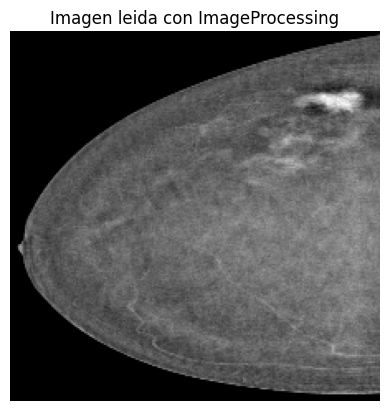

In [7]:
img_array = img_processor.resize_rescale_image(img_array)
plt.imshow(img_array, cmap='gray')
plt.title("Imagen leida con ImageProcessing")
plt.axis('off')
plt.show()

# OPP for data processing

## Matrix operations

Classes ImageProcessing and MaskGenerator correspond to matrix operations.

In [4]:
class ImageProcessing:
  def __init__(self, image_path):
    self.image_path = image_path
  def read_dicom_image(self,image_path):
    image_raw = sitk.ReadImage(image_path)
    image = sitk.GetArrayFromImage(image_raw)
    return image
  def resize_rescale_image(self,image_array=None, new_shape_x = 224, new_shape_y = 224):
    img = image_array if image_array is not None else self.read_dicom_image()
    resized_image = cv2.resize(img, (new_shape_x, new_shape_y))
    rescaled_image = (resized_image - 127.5)*2 / 255
    return rescaled_image

In [8]:
class MaskGenerator:
    def __init__(self, csv_path, images_dir):
        self.df = pd.read_csv(csv_path)
        self.images_dir = images_dir
        self.rois_by_image = self.df.groupby('img_name')

    def get_image_shape(self, img_name):
        img_path = f"{self.images_dir}/{img_name}"
        with Image.open(img_path) as img:
            return img.size[::-1]

    def get_mask(self, img_name):
        height, width = self.get_image_shape(img_name)
        mask = np.zeros((height, width), dtype=np.uint8)
        rois = self.df[self.df['img_name'] == img_name]
        for _, row in rois.iterrows():
            ymin, ymax, xmin, xmax = int(row['ymin']), int(row['ymax']), int(row['xmin']), int(row['xmax'])
            mask[ymin:ymax, xmin:xmax] = 1
        return mask

    def save_mask(self, img_name, out_path):
        mask = self.get_mask(img_name)
        mask_img = Image.fromarray(mask * 255)
        mask_img.save(out_path)


In [10]:
class ROICutter:
    def __init__(self, csv_path, images_dir, output_dir):
        self.csv_path = csv_path
        self.images_dir = images_dir
        self.output_dir = output_dir
        self.df = pd.read_csv(csv_path, header=None, names=['image', 'x1', 'y1', 'x2', 'y2'])
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)

    def cut_all(self):
        grouped = self.df.groupby('image')
        for image_name, group in grouped:
            image_path = os.path.join(self.images_dir, image_name)
            if not os.path.exists(image_path):
                print(f"Imagen no encontrada: {image_path}")
                continue
            try:
                img = Image.open(image_path)
            except Exception as e:
                print(f"Error abriendo {image_path}: {e}")
                continue

            for idx, row in group.iterrows():
                x1, y1, x2, y2 = int(row['x1']), int(row['y1']), int(row['x2']), int(row['y2'])
                left, upper, right, lower = min(x1, x2), min(y1, y2), max(x1, x2), max(y1, y2)
                left = max(left, 0)
                upper = max(upper, 0)
                right = min(right, img.width)
                lower = min(lower, img.height)
                if left >= right or upper >= lower:
                    print(f"Coordenadas inválidas para {image_name}: {left}, {upper}, {right}, {lower}")
                    continue
                crop = img.crop((left, upper, right, lower))
                base_name = os.path.splitext(image_name)[0]
                out_name = f"{base_name}_cut{list(group.index).index(idx)}.png"
                out_path = os.path.join(self.output_dir, out_name)
                crop.save(out_path)
                print(f"Guardado: {out_path}")

In [ ]:
ROICutter("detections.csv", "images", "output").cut_all()

Guardado: output/SCEDM003_L_CC_cut0.png
Guardado: output/SCEDM003_L_CC_cut1.png
Guardado: output/SCEDM003_L_ML_cut0.png
Guardado: output/SCEDM003_L_ML_cut1.png
Guardado: output/SCEDM003_L_MLO_cut0.png
Guardado: output/SCEDM003_L_MLO_cut1.png
Guardado: output/SCEDM003_R_CC_cut0.png
Guardado: output/SCEDM003_R_ML_cut0.png
Guardado: output/SCEDM003_R_ML_cut1.png
Guardado: output/SCEDM003_R_MLO_cut0.png
Guardado: output/SCEDM018_L_CC_cut0.png
Guardado: output/SCEDM018_L_ML_cut0.png
Guardado: output/SCEDM018_L_ML_cut1.png
Guardado: output/SCEDM018_L_MLO_cut0.png
Guardado: output/SCEDM018_L_MLO_cut1.png
Guardado: output/SCEDM018_L_MLO_2_cut0.png
Guardado: output/SCEDM018_L_MLO_2_cut1.png
Guardado: output/SCEDM018_L_ML_6_cut0.png
Guardado: output/SCEDM018_R_CC_cut0.png
Guardado: output/SCEDM018_R_CC_cut1.png
Guardado: output/SCEDM018_R_MLO_cut0.png
Guardado: output/SCEDM018_R_MLO_cut1.png
Guardado: output/SCEDM024_L_CC_cut0.png
Guardado: output/SCEDM024_L_CC_4_cut0.png
Guardado: output/SCEDM0

In [ ]:
class LesionMaskExtractor:
    def __init__(self, sobel_ksize=3, morph_ksize=5):
        self.sobel_ksize = sobel_ksize

    def extract_mask(self, img):
        gray = img.copy()
        sobel_x = np.array([[-1, 0, 1],
                            [-2, 0, 2],
                            [-1, 0, 1]])

        sobel_y = np.array([[-1, -2, -1],
                            [ 0,  0,  0],
                            [ 1,  2,  1]])

        Gx = ndimage.convolve(gray, sobel_x)
        Gy = ndimage.convolve(gray, sobel_y)
        G = np.sqrt(Gx**2 + Gy**2)
        G = np.uint8(255 * G / np.max(G))
        _, binary = cv2.threshold(G, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        mask = binary

        return mask


In [ ]:
import glob

input_folder = "output"
output_folder = "mascaras"
os.makedirs(output_folder, exist_ok=True)
extractor = LesionMaskExtractor()

for img_path in glob.glob(os.path.join(input_folder, "*.png")):
    img = cv2.imread(img_path)
    mask = extractor.extract_mask(img)
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    output_path = os.path.join(output_folder, f"{base_name}_mask.png")
    extractor.save_mask_as_png(mask, output_path)
    print(f"Guardada máscara en: {output_path}")

Guardada máscara en: mascaras/SCEDM118_R_CC_cut0_mask.png
Guardada máscara en: mascaras/SCEDM65_R_CC_cut0_mask.png
Guardada máscara en: mascaras/SCEDM77_R_MLO_cut1_mask.png
Guardada máscara en: mascaras/SCEDM003_R_ML_cut1_mask.png
Guardada máscara en: mascaras/SCEDM054_R_MLO_cut0_mask.png
Guardada máscara en: mascaras/SCEDM79_L_XCCL_cut0_mask.png
Guardada máscara en: mascaras/SCEDM65_L_MLO_cut1_mask.png
Guardada máscara en: mascaras/SCEDM018_L_ML_cut1_mask.png
Guardada máscara en: mascaras/SCEDM87_L_CC_cut0_mask.png
Guardada máscara en: mascaras/SCEDM63_R_CC_cut0_mask.png
Guardada máscara en: mascaras/SCEDM87_R_MLO_cut1_mask.png
Guardada máscara en: mascaras/SCEDM77_R_CC_cut0_mask.png
Guardada máscara en: mascaras/SCEDM90_R_CC_cut0_mask.png
Guardada máscara en: mascaras/SCEDM003_L_CC_cut0_mask.png
Guardada máscara en: mascaras/SCEDM60_R_MLO_cut1_mask.png
Guardada máscara en: mascaras/SCEDM054_R_CC_cut1_mask.png
Guardada máscara en: mascaras/SCEDM79_L_ML_cut0_mask.png
Guardada máscara e

In [ ]:
from radiomics import featureextractor
class Radiomics:
    def __init__(self, image_path, segmentation_path):
        self.image_path = image_path
        self.segmentation_path = segmentation_path
        self.image = ImageProcessing.read_dicom_image(self.image_path)
        self.segmentation = ImageProcessing.read_dicom_image(self.segmentation_path)

    def radiomics_features(self):
        params = {
            'binWidth': 10,
            'resampledPixelSpacing': None,
            'interpolator': 'sitkBSpline',
            'normalize': False,
            'enableCExtensions': True
        }
        extractor = featureextractor.RadiomicsFeatureExtractor(**params)
        extractor.enableFeatureClassByName('firstorder')
        extractor.enableFeatureClassByName('glcm')
        extractor.enableFeatureClassByName('glrlm')
        extractor.enableFeatureClassByName('glszm')
        extractor.enableFeatureClassByName('gldm')
        extractor.enableFeatureClassByName('ngtdm')
        result = extractor.execute(self.image, self.segmentation)
        features = {k: v for k, v in result.items() if 'diagnostics' not in k}
        df = pd.DataFrame([features])
        return df

## Numerical derivation of data


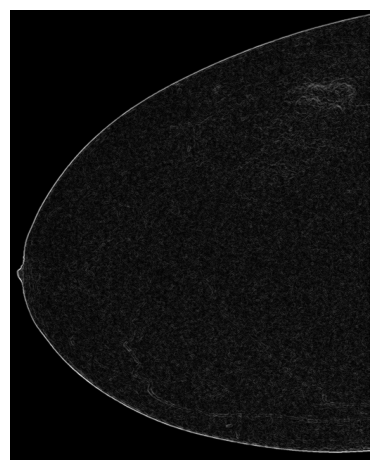

In [14]:
def derivar_imagen(path):
    img = sitk.ReadImage(path)
    I = sitk.GetArrayFromImage(img).astype(np.float32)
    Ix = np.zeros_like(I, dtype=np.float32)
    Iy = np.zeros_like(I, dtype=np.float32)
    Ix[:, 1:-1] = I[:, 2:] - I[:, :-2]
    Iy[1:-1, :] = I[2:, :] - I[:-2, :]
    mag = np.sqrt(Ix**2 + Iy**2)
    plt.imshow(mag, cmap="gray")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


derivar_imagen("/content/SCEDM63_R_CC.png")

# Conclusions and Discussion 

This work allowed me to engage directly with the images, improving my understanding of their manipulation and preprocessing, and it also led to the successful implementation of a radiomic feature-extraction workflow for my dataset.

The derivation applied to the image allowed the breast contour to be adequately highlighted. However, this result was obtained only on a small set of test images used for initial evaluation purposes. Therefore, it is necessary to validate the performance of the technique on a larger and more diverse group of images in order to ensure its robustness and generalization in different clinical scenarios
